# 04. Visualizacao dos Dados (EDA)
# CRISP-DM - Fase 3: Analise dos Dados

Analise exploratoria visual do snapshot pre-limpeza (`dados_tratados_pre_eda.csv`), gerado no notebook 02 antes da limpeza orientada por EDA.

Objetivos desta etapa antes da modelagem:

1. analisar visualmente as variaveis por histogramas, distribuicoes e boxplots;
2. identificar outliers e codigos extremos que podem distorcer o treinamento;
3. identificar colunas desnecessarias por baixa variancia, alta redundancia ou ausencia de valor preditivo;
4. registrar as regras que devem ser aplicadas no notebook `02.Preparacao_dos_dados.ipynb`.


## 1. Importacao das Bibliotecas

In [1]:
# CRISP-DM: analise de dados fase 3
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('default')

print('Bibliotecas importadas com sucesso!')


Bibliotecas importadas com sucesso!


## 2. Carregamento do Dataset Tratado

In [2]:
# Caminhos robustos para execucao a partir da pasta do notebook ou da raiz do repositorio
BASE_DIR = Path.cwd()
if BASE_DIR.name == '2_NoteBooks_Etapas_Projeto':
    RAIZ_PROJETO = BASE_DIR.parent
elif (BASE_DIR / 'trabalhoFinal').exists():
    RAIZ_PROJETO = BASE_DIR / 'trabalhoFinal'
else:
    RAIZ_PROJETO = BASE_DIR

CAMINHO_CSV = RAIZ_PROJETO / 'datasets' / 'dados_tratados_pre_eda.csv'
if not CAMINHO_CSV.exists():
    CAMINHO_CSV = RAIZ_PROJETO / 'datasets' / 'dados_tratados.csv'
CAMINHO_IMAGENS = RAIZ_PROJETO / 'imagens'
CAMINHO_IMAGENS.mkdir(parents=True, exist_ok=True)

def carregarDados(caminho):
    dados = None
    try:
        dados = pd.read_csv(caminho, sep=';', encoding='utf-8-sig')
        dados.columns = dados.columns.str.replace('\ufeff', '', regex=False)
        print('Dataset carregado com sucesso!')
        print(f'  Registros : {dados.shape[0]:,}')
        print(f'  Colunas   : {dados.shape[1]}')
    except Exception as e:
        print(f'Nao foi possivel carregar os dados: {e}')
    return dados

df = carregarDados(CAMINHO_CSV)


Dataset carregado com sucesso!
  Registros : 17,583
  Colunas   : 227


## 3. Inspecao Inicial dos Dados

In [3]:
print('=== INFO ===')
print(df.info())

print('\n=== PRIMEIROS REGISTROS ===')
display(df.head())

print('\n=== ESTATISTICAS BASICAS ===')
display(df.describe(include='all').T.head(25))

print('\n=== VALORES AUSENTES ===')
print(f'Total de valores ausentes: {int(df.isna().sum().sum())}')


=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 17583 entries, 0 to 17582
Columns: 227 entries, SG_UF to IDEB_2025
dtypes: float64(221), int64(4), str(2)
memory usage: 30.5 MB
None

=== PRIMEIROS REGISTROS ===


,SG_UF,CO_UF,NO_ENTIDADE,CO_ENTIDADE,TP_DEPENDENCIA,TP_LOCALIZACAO,IN_LOCAL_FUNC_PREDIO_ESCOLAR,TP_OCUPACAO_PREDIO_ESCOLAR,IN_LOCAL_FUNC_SOCIOEDUCATIVO,IN_LOCAL_FUNC_UNID_PRISIONAL,...,IN_ESP_EXCLUSIVA_MEDIO_INTEGR,IN_COMUM_EJA_FUND,IN_COMUM_EJA_MEDIO,IN_COMUM_EJA_PROF,IN_ESP_EXCLUSIVA_EJA_FUND,IN_ESP_EXCLUSIVA_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_PROF,IN_COMUM_PROF,IN_ESP_EXCLUSIVA_PROF,IDEB_2025
0,RO,11,EEEMTI JUSCELINO KUBITSCHEK DE OLIVEIRA,11024968,2,1,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.1
1,RO,11,COLEGIO TIRADENTES DA POLICIA MILITAR - CTPM XI,11025638,2,1,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.8
2,RO,11,EEEFM CORA CORALINA,11006773,2,1,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.4
3,RO,11,EEEFM ANISIO TEIXEIRA,11006889,2,1,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.8
4,RO,11,COLEGIO TIRADENTES DA POLICIA MILITAR - CTPM III,11007168,2,1,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.8



=== ESTATISTICAS BASICAS ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SG_UF,17583,27,SP,3402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO_UF,17583.0,NaN,NaN,NaN,32.081613,9.59225,11.0,26.0,32.0,35.0,53.0
NO_ENTIDADE,17583,17017,EE DE ENSINO MEDIO,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO_ENTIDADE,17583.0,NaN,NaN,NaN,32219089.688108,9588211.888823,11000260.0,26040250.0,32027753.0,35922365.0,53068181.0
TP_DEPENDENCIA,17583.0,NaN,NaN,NaN,1.9909,0.132901,1.0,2.0,2.0,2.0,3.0
TP_LOCALIZACAO,17583.0,NaN,NaN,NaN,1.114144,0.317996,1.0,1.0,1.0,1.0,2.0
IN_LOCAL_FUNC_PREDIO_ESCOLAR,17583.0,NaN,NaN,NaN,0.994881,0.071363,0.0,1.0,1.0,1.0,1.0
TP_OCUPACAO_PREDIO_ESCOLAR,17583.0,NaN,NaN,NaN,1.186487,0.580829,0.0,1.0,1.0,1.0,3.0
IN_LOCAL_FUNC_SOCIOEDUCATIVO,17583.0,NaN,NaN,NaN,0.002673,0.051634,0.0,0.0,0.0,0.0,1.0
IN_LOCAL_FUNC_UNID_PRISIONAL,17583.0,NaN,NaN,NaN,0.008872,0.093776,0.0,0.0,0.0,0.0,1.0



=== VALORES AUSENTES ===
Total de valores ausentes: 0


## 4. Classificacao das Variaveis

Separacao das variaveis numericas entre binarias, quantitativas e identificadores/codigos. Essa classificacao orienta quais visualizacoes e regras de limpeza fazem sentido para cada grupo.

In [4]:
def classificarVariaveis(dados, target='IDEB_2025'):
    numericas = dados.select_dtypes(include=[np.number]).columns.tolist()
    categoricas = dados.select_dtypes(exclude=[np.number]).columns.tolist()

    binarias = [
        c for c in numericas
        if c != target and set(dados[c].dropna().unique()).issubset({0, 1})
    ]

    identificadores_codigos = [
        c for c in numericas
        if c.startswith('CO_') or c.startswith('TP_')
    ]

    quantitativas = [
        c for c in numericas
        if c != target and c not in binarias and c not in identificadores_codigos
    ]

    resumo = pd.DataFrame({
        'Grupo': ['Numericas', 'Binarias 0/1', 'Quantitativas', 'Codigos/Tipos numericos', 'Categoricas/texto'],
        'Quantidade': [len(numericas), len(binarias), len(quantitativas), len(identificadores_codigos), len(categoricas)]
    })

    display(resumo)
    print(f'Variaveis categoricas/texto: {categoricas}')
    return numericas, binarias, quantitativas, identificadores_codigos, categoricas

numericas, binarias, quantitativas, identificadores_codigos, categoricas = classificarVariaveis(df)


,Grupo,Quantidade
0,Numericas,225
1,Binarias 0/1,164
2,Quantitativas,48
3,Codigos/Tipos numericos,15
4,Categoricas/texto,2


Variaveis categoricas/texto: ['SG_UF', 'NO_ENTIDADE']


## 5. Distribuicao do Target - IDEB_2025

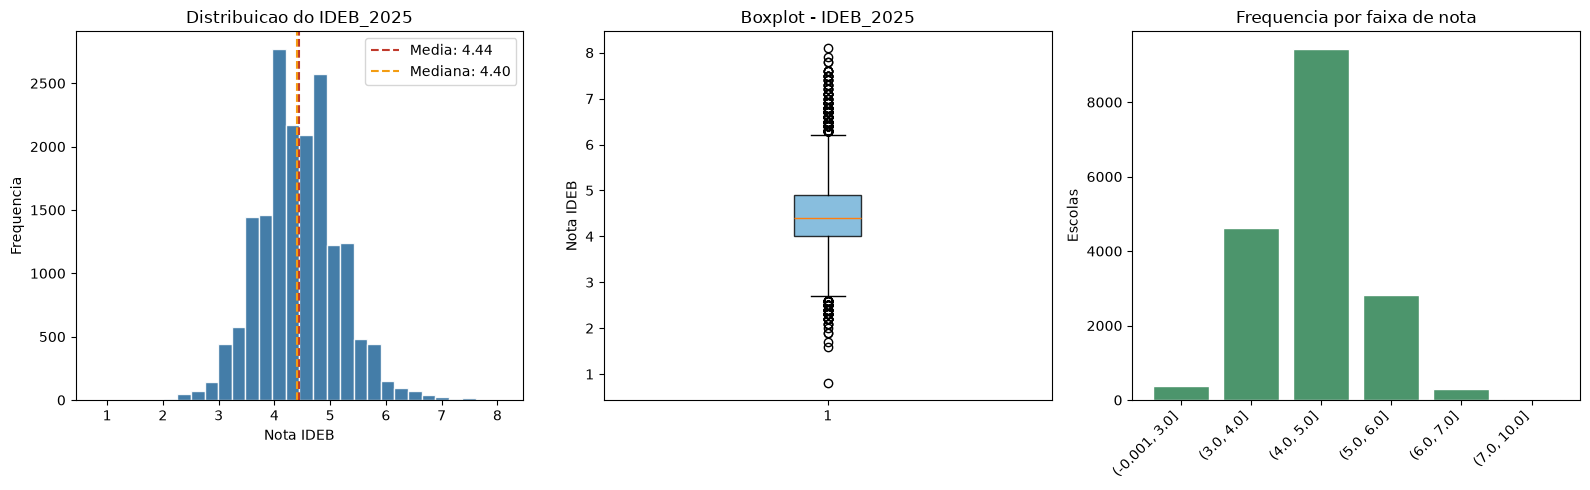

,IDEB_2025
count,17583.000000
mean,4.441193
std,0.710609
min,0.800000
25%,4.000000
50%,4.400000
75%,4.900000
max,8.100000


In [5]:
def visualizarDistribuicaoTarget(dados, coluna='IDEB_2025'):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    serie = dados[coluna].dropna()
    axes[0].hist(serie, bins=30, color='#2f6f9f', edgecolor='white', alpha=0.9)
    axes[0].axvline(serie.mean(), color='#c0392b', linestyle='--', label=f'Media: {serie.mean():.2f}')
    axes[0].axvline(serie.median(), color='#f39c12', linestyle='--', label=f'Mediana: {serie.median():.2f}')
    axes[0].set_title(f'Distribuicao do {coluna}')
    axes[0].set_xlabel('Nota IDEB')
    axes[0].set_ylabel('Frequencia')
    axes[0].legend()

    axes[1].boxplot(serie, patch_artist=True, boxprops=dict(facecolor='#6aaed6', alpha=0.8))
    axes[1].set_title(f'Boxplot - {coluna}')
    axes[1].set_ylabel('Nota IDEB')

    faixas = pd.cut(serie, bins=[0, 3, 4, 5, 6, 7, 10], include_lowest=True)
    contagem = faixas.value_counts().sort_index()
    axes[2].bar(range(len(contagem)), contagem.values, color='#4c956c', edgecolor='white')
    axes[2].set_xticks(range(len(contagem)))
    axes[2].set_xticklabels([str(i) for i in contagem.index], rotation=45, ha='right')
    axes[2].set_title('Frequencia por faixa de nota')
    axes[2].set_ylabel('Escolas')

    plt.tight_layout()
    plt.savefig(CAMINHO_IMAGENS / 'distribuicao_target.png', dpi=150, bbox_inches='tight')
    plt.show()

    display(serie.describe().to_frame('IDEB_2025'))

visualizarDistribuicaoTarget(df)


## 6. Histogramas das Variaveis Quantitativas

Histogramas das variaveis de contagem com maior variancia. Eles ajudam a diferenciar assimetria natural de escolas grandes de codigos invalidos extremos.

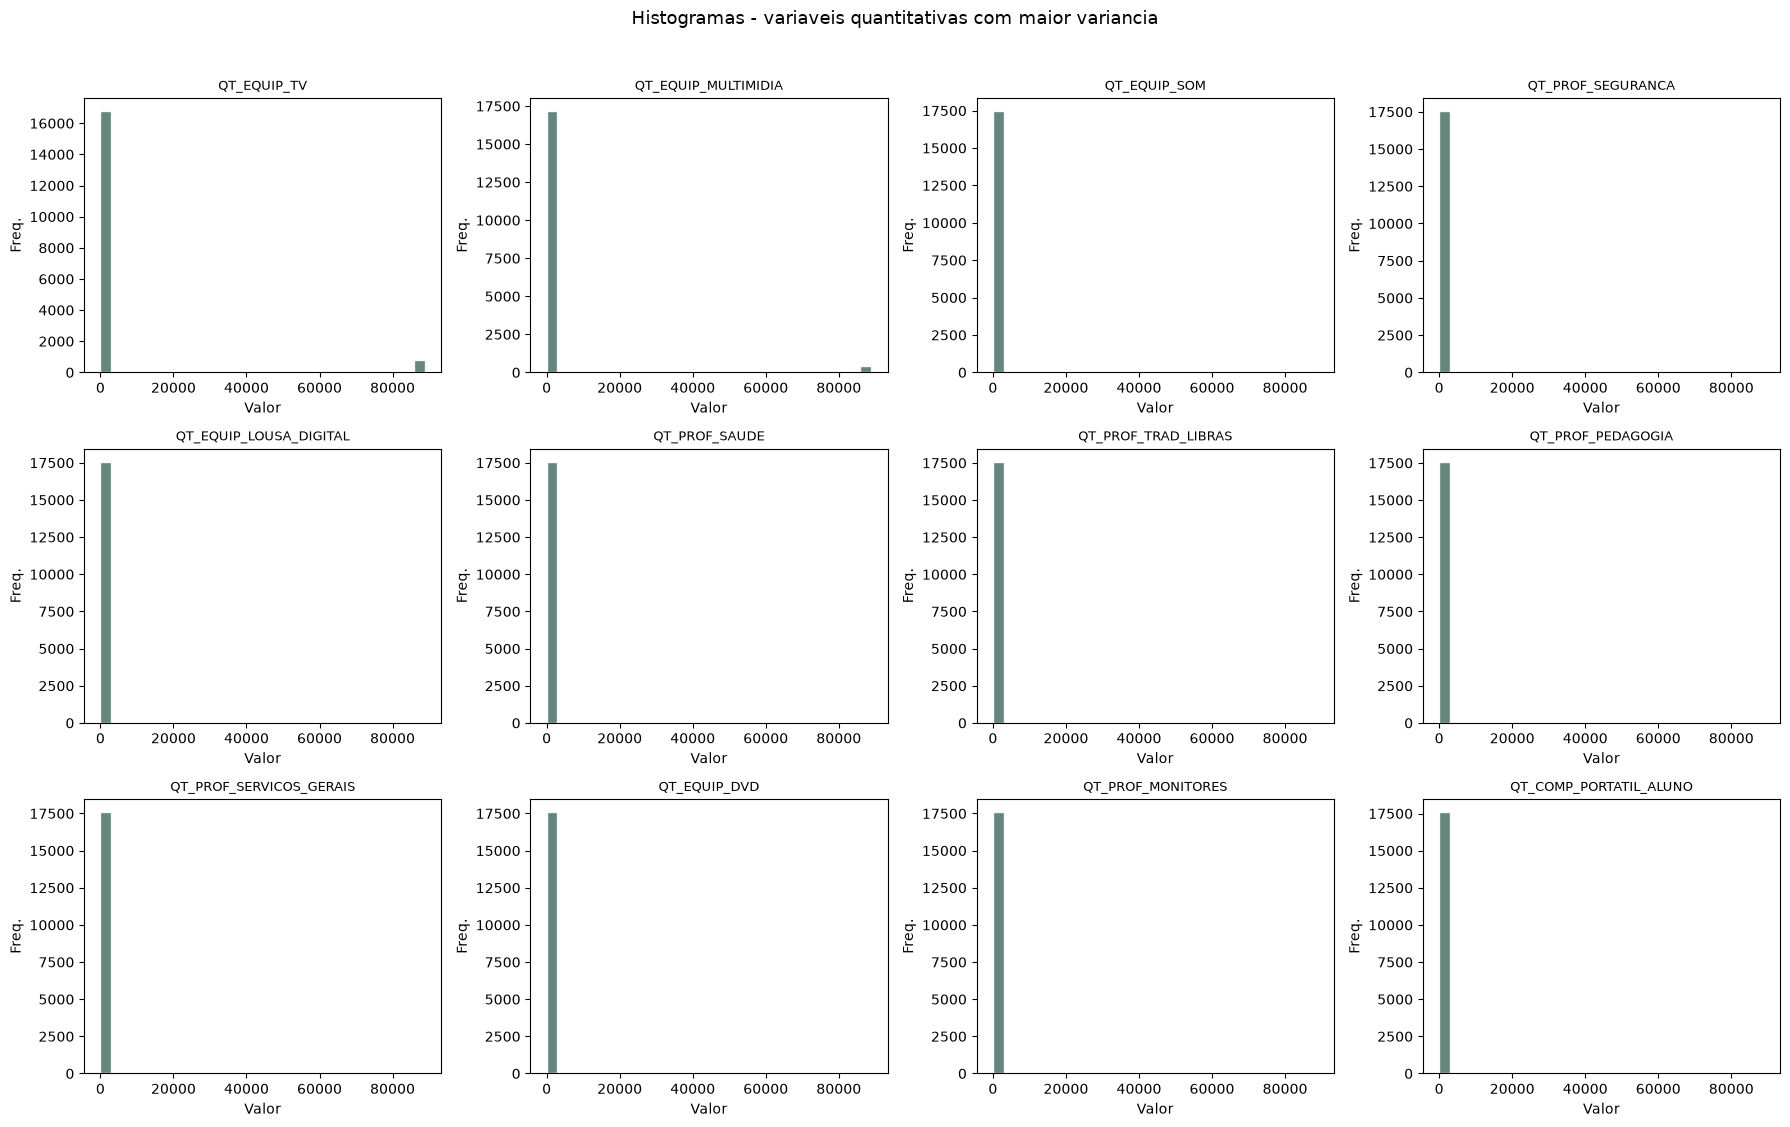

In [6]:
def visualizarHistogramasQuantitativas(dados, colunas_quantitativas, top_n=12):
    colunas = sorted(
        colunas_quantitativas,
        key=lambda c: dados[c].var(),
        reverse=True
    )[:top_n]

    fig, axes = plt.subplots(3, 4, figsize=(18, 11))
    axes = axes.flatten()

    for ax, col in zip(axes, colunas):
        serie = dados[col].dropna()
        ax.hist(serie, bins=30, color='#52796f', edgecolor='white', alpha=0.9)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel('Valor')
        ax.set_ylabel('Freq.')

    for ax in axes[len(colunas):]:
        ax.axis('off')

    plt.suptitle('Histogramas - variaveis quantitativas com maior variancia', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(CAMINHO_IMAGENS / 'histogramas_variaveis_quantitativas.png', dpi=150, bbox_inches='tight')
    plt.show()

visualizarHistogramasQuantitativas(df, quantitativas)


## 7. Boxplots das Variaveis Quantitativas

Para comparar variaveis em escalas diferentes, os boxplots abaixo usam valores padronizados por mediana e IQR. A escala padronizada evidencia dispersao e pontos extremos sem deixar uma unica coluna dominar o grafico.

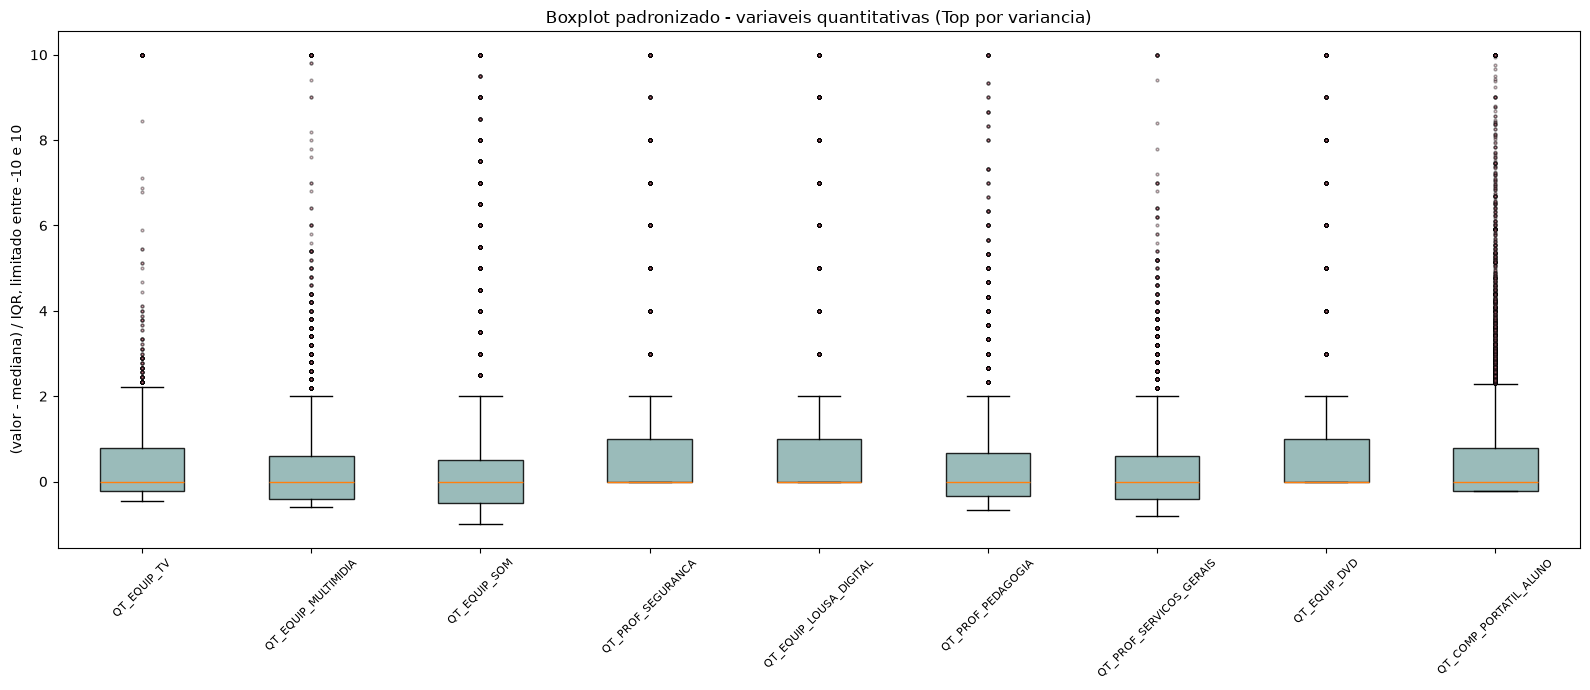

In [8]:
def gerarBoxplot(dados, colunas_quantitativas, top_n=12):
    colunas = sorted(
        colunas_quantitativas,
        key=lambda c: dados[c].var(),
        reverse=True
    )[:top_n]

    dados_plot = pd.DataFrame(index=dados.index)
    for col in colunas:
        serie = dados[col].astype(float)
        iqr = serie.quantile(0.75) - serie.quantile(0.25)
        if iqr == 0:
            continue
        dados_plot[col] = ((serie - serie.median()) / iqr).clip(-10, 10)

    fig, ax = plt.subplots(figsize=(16, 7))
    bp = ax.boxplot(
        [dados_plot[col].dropna().values for col in dados_plot.columns],
        patch_artist=True,
        tick_labels=dados_plot.columns,
        flierprops=dict(marker='o', markersize=2, markerfacecolor='#b56576', alpha=0.35),
    )
    for patch in bp['boxes']:
        patch.set_facecolor('#89b0ae')
        patch.set_alpha(0.85)
    ax.set_title('Boxplot padronizado - variaveis quantitativas (Top por variancia)')
    ax.set_ylabel('(valor - mediana) / IQR, limitado entre -10 e 10')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    plt.tight_layout()
    plt.savefig(CAMINHO_IMAGENS / 'boxplot_variaveis.png', dpi=150, bbox_inches='tight')
    plt.show()

gerarBoxplot(df, quantitativas)


## 8. Distribuicao das Variaveis Binarias (IN_*)

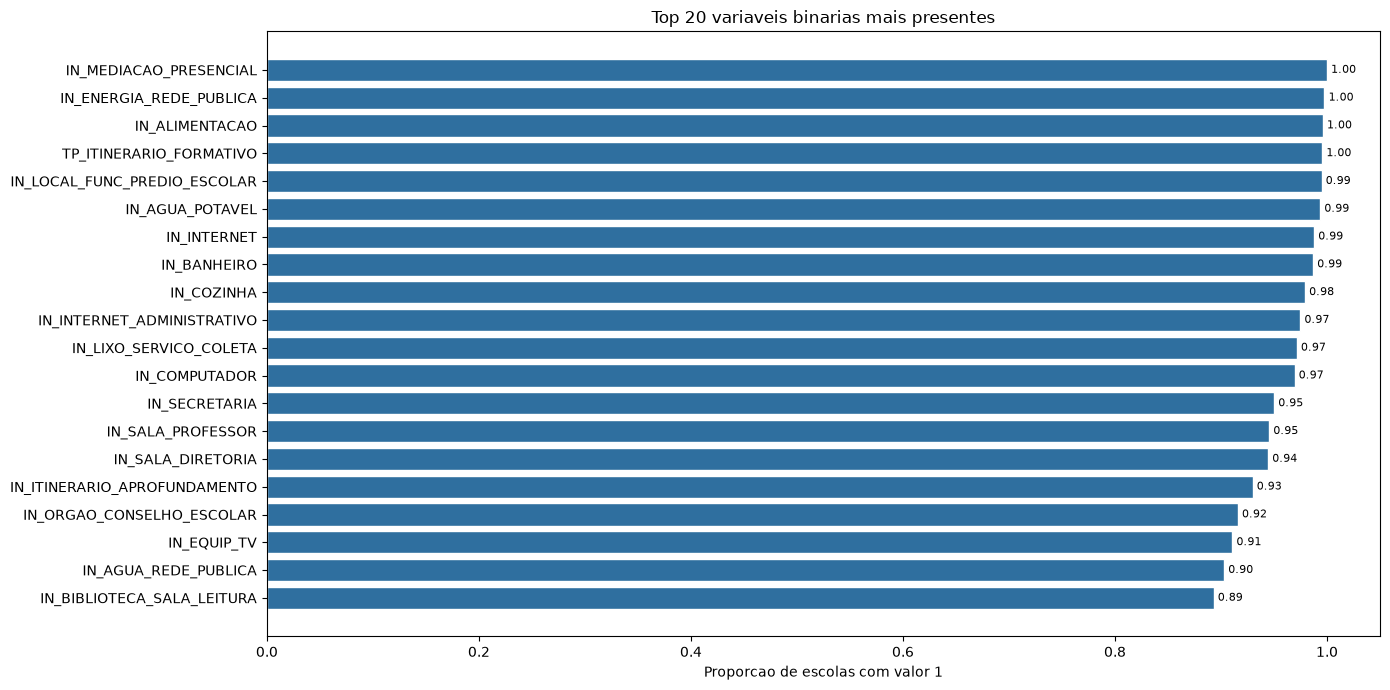

Total de variaveis binarias validas 0/1: 164


In [9]:
def visualizarVariaveisBinarias(dados, colunas_binarias, top_n=20):
    proporcoes = dados[colunas_binarias].mean().sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(14, 7))
    bars = plt.barh(proporcoes.index[::-1], proporcoes.values[::-1], color='#2f6f9f', edgecolor='white')
    plt.xlabel('Proporcao de escolas com valor 1')
    plt.title(f'Top {top_n} variaveis binarias mais presentes')
    plt.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    plt.xlim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CAMINHO_IMAGENS / 'proporcao_variaveis_binarias.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Total de variaveis binarias validas 0/1: {len(colunas_binarias)}')

visualizarVariaveisBinarias(df, binarias)


## 9. Diagnostico e Remocao Recomendada de Outliers

Foram separados dois tipos de outliers:

- **codigos invalidos/extremos**: valores como `88888` em contagens e `9` em indicadores `IN_*`, que distorcem o treinamento;
- **outliers estatisticos por IQR**: valores altos em contagens que podem representar escolas grandes reais. Estes sao reportados, mas nao removidos automaticamente por IQR para evitar perda excessiva de dados validos.

Linhas com pelo menos um valor 88888: 1,326 (7.54%)
Linhas com indicador IN_* invalido apos remover detalhamento ambiental: 358 (2.04%)

Colunas com codigo 88888:


,Coluna,Qtd_88888,Pct
2,QT_EQUIP_TV,812,0.046181
4,QT_EQUIP_MULTIMIDIA,422,0.024000
1,QT_EQUIP_SOM,123,0.006995
14,QT_PROF_SEGURANCA,44,0.002502
3,QT_EQUIP_LOUSA_DIGITAL,18,0.001024
10,QT_PROF_SAUDE,15,0.000853
16,QT_PROF_TRAD_LIBRAS,9,0.000512
13,QT_PROF_PEDAGOGIA,7,0.000398
8,QT_PROF_SERVICOS_GERAIS,7,0.000398
0,QT_EQUIP_DVD,6,0.000341



Indicadores IN_* com valores fora de 0/1:


,Coluna,Qtd_invalida
4,IN_ACESSO_INTERNET_COMPUTADOR,301
5,IN_ACES_INTERNET_DISP_PESSOAIS,301
9,IN_ESPACO_EQUIPAMENTO,50
8,IN_ESPACO_ATIVIDADE,12
7,IN_REDES_SOCIAIS,5
0,IN_TRATAMENTO_LIXO_SEPARACAO,3
1,IN_TRATAMENTO_LIXO_REUTILIZA,3
3,IN_TRATAMENTO_LIXO_INEXISTENTE,3
2,IN_TRATAMENTO_LIXO_RECICLAGEM,3
6,IN_EXAME_SELECAO,3



Top outliers por regra IQR (diagnostico, sem remocao automatica):


,Coluna,Outliers_IQR,Pct,Limite_inf,Limite_sup,Max
21,QT_PROF_SEGURANCA,3063,0.174202,-1.50,2.50,88888.0
13,QT_TABLET_ALUNO,1659,0.094352,-33.00,55.00,1426.0
10,QT_EQUIP_MULTIMIDIA,1333,0.075812,-6.50,13.50,88888.0
7,QT_EQUIP_SOM,1323,0.075243,-2.00,6.00,88888.0
12,QT_COMP_PORTATIL_ALUNO,1223,0.069556,-77.00,131.00,88888.0
6,QT_EQUIP_DVD,1211,0.068873,-1.50,2.50,88888.0
9,QT_EQUIP_LOUSA_DIGITAL,1013,0.057612,-1.50,2.50,88888.0
8,QT_EQUIP_TV,948,0.053916,-11.50,24.50,88888.0
19,QT_PROF_ALIMENTACAO,884,0.050276,-1.00,7.00,33.0
20,QT_PROF_PEDAGOGIA,820,0.046636,-3.50,8.50,88888.0


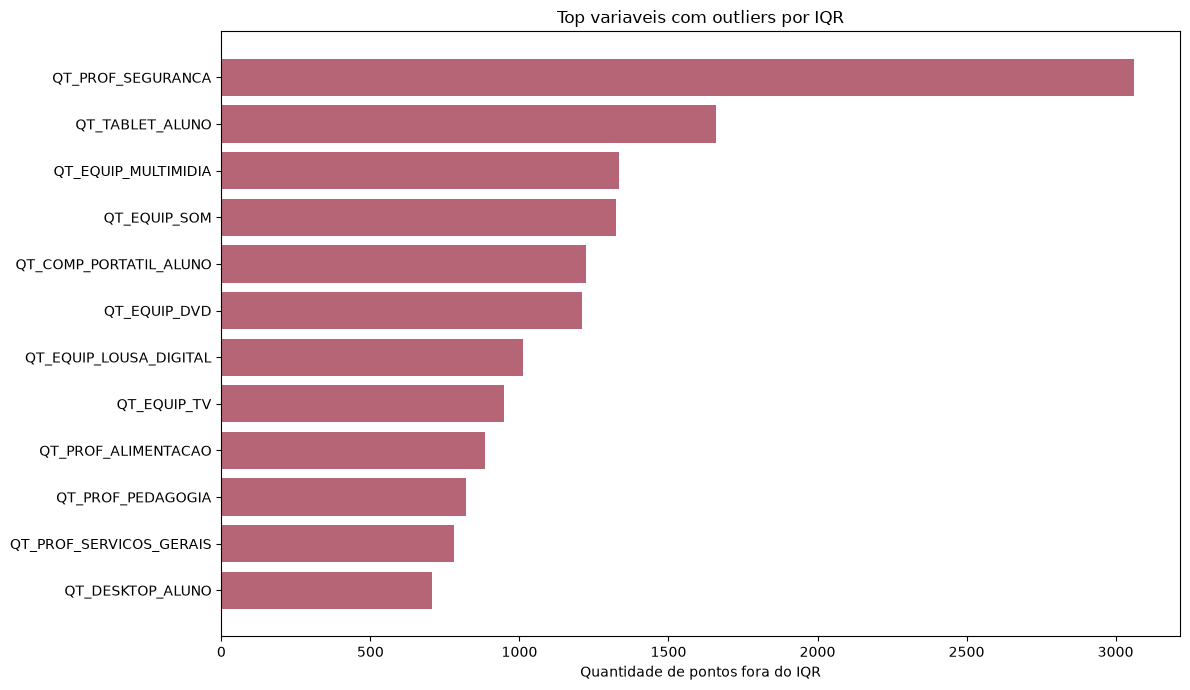

In [10]:
COLUNAS_EDUC_AMBIENTAL_DETALHADAS = [
    'IN_EDUC_AMB_CONTEUDO',
    'IN_EDUC_AMB_CURRICULAR',
    'IN_EDUC_AMB_EIXO',
    'IN_EDUC_AMB_EVENTOS',
    'IN_EDUC_AMB_PROJETOS',
    'IN_EDUC_AMB_NENHUMA',
]

def diagnosticarOutliers(dados, colunas_quantitativas):
    numericas_local = dados.select_dtypes(include=[np.number])

    colunas_com_88888 = []
    for col in numericas_local.columns:
        qtd = int((numericas_local[col] == 88888).sum())
        if qtd > 0:
            colunas_com_88888.append({'Coluna': col, 'Qtd_88888': qtd, 'Pct': qtd / len(dados)})

    mask_88888 = (numericas_local == 88888).any(axis=1)

    dados_sem_educ_detalhada = dados.drop(columns=COLUNAS_EDUC_AMBIENTAL_DETALHADAS, errors='ignore')
    numericas_sem_educ = dados_sem_educ_detalhada.select_dtypes(include=[np.number])
    colunas_in = [c for c in numericas_sem_educ.columns if c.startswith('IN_')]

    colunas_in_invalidas = []
    mask_in_invalido = pd.Series(False, index=dados.index)
    for col in colunas_in:
        invalido = ~numericas_sem_educ[col].isin([0, 1])
        qtd = int(invalido.sum())
        if qtd > 0:
            colunas_in_invalidas.append({'Coluna': col, 'Qtd_invalida': qtd})
            mask_in_invalido |= invalido.fillna(False)

    resumo_iqr = []
    for col in colunas_quantitativas + ['IDEB_2025']:
        serie = numericas_local[col].dropna()
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            continue
        limite_inf = q1 - 1.5 * iqr
        limite_sup = q3 + 1.5 * iqr
        qtd = int(((numericas_local[col] < limite_inf) | (numericas_local[col] > limite_sup)).sum())
        if qtd > 0:
            resumo_iqr.append({
                'Coluna': col,
                'Outliers_IQR': qtd,
                'Pct': qtd / len(dados),
                'Limite_inf': limite_inf,
                'Limite_sup': limite_sup,
                'Max': serie.max()
            })

    df_88888 = pd.DataFrame(colunas_com_88888).sort_values('Qtd_88888', ascending=False)
    df_invalido = pd.DataFrame(colunas_in_invalidas).sort_values('Qtd_invalida', ascending=False)
    df_iqr = pd.DataFrame(resumo_iqr).sort_values('Outliers_IQR', ascending=False)

    print(f'Linhas com pelo menos um valor 88888: {int(mask_88888.sum()):,} ({mask_88888.mean():.2%})')
    print(f'Linhas com indicador IN_* invalido apos remover detalhamento ambiental: {int(mask_in_invalido.sum()):,} ({mask_in_invalido.mean():.2%})')

    print('\nColunas com codigo 88888:')
    display(df_88888)

    print('\nIndicadores IN_* com valores fora de 0/1:')
    display(df_invalido)

    print('\nTop outliers por regra IQR (diagnostico, sem remocao automatica):')
    display(df_iqr.head(20))

    if not df_iqr.empty:
        top_iqr = df_iqr.head(12).sort_values('Outliers_IQR')
        plt.figure(figsize=(12, 7))
        plt.barh(top_iqr['Coluna'], top_iqr['Outliers_IQR'], color='#b56576')
        plt.xlabel('Quantidade de pontos fora do IQR')
        plt.title('Top variaveis com outliers por IQR')
        plt.tight_layout()
        plt.savefig(CAMINHO_IMAGENS / 'outliers_iqr_top.png', dpi=150, bbox_inches='tight')
        plt.show()

    return df_88888, df_invalido, df_iqr

df_88888, df_invalido, df_iqr = diagnosticarOutliers(df, quantitativas)


## 10. Identificacao de Colunas Desnecessarias

Criterios usados:

- variaveis identificadoras ou textuais que nao podem entrar diretamente nos modelos (`SG_UF`, `NO_ENTIDADE`, `CO_ENTIDADE`);
- variaveis quase constantes, com pelo menos 99,5% dos registros no mesmo valor;
- variaveis altamente redundantes, especialmente detalhamentos ambientais quase perfeitamente correlacionados;
- colunas de modalidade/lingua muito raras, que carregam baixissimo sinal preditivo no recorte analisado.

In [11]:
COLUNAS_IDENTIFICACAO = ['SG_UF', 'NO_ENTIDADE', 'CO_ENTIDADE']

COLUNAS_BAIXA_VARIANCIA = [
    'IN_LOCAL_FUNC_SOCIOEDUCATIVO',
    'IN_LOCAL_FUNC_GALPAO',
    'TP_OCUPACAO_GALPAO',
    'IN_AGUA_INEXISTENTE',
    'IN_ENERGIA_REDE_PUBLICA',
    'IN_ENERGIA_GERADOR_FOSSIL',
    'IN_ENERGIA_INEXISTENTE',
    'QT_PROF_FONAUDIOLOGO',
    'IN_ALIMENTACAO',
    'CO_LINGUA_INDIGENA_1',
    'CO_LINGUA_INDIGENA_2',
    'CO_LINGUA_INDIGENA_3',
    'TP_ITINERARIO_FORMATIVO',
    'IN_MEDIACAO_PRESENCIAL',
    'IN_MEDIACAO_SEMIPRESENCIAL',
    'IN_ESPECIAL_EXCLUSIVA',
    'IN_COMUM_CRECHE',
    'IN_COMUM_PRE',
    'IN_ESP_EXCLUSIVA_PRE',
    'IN_ESP_EXCLUSIVA_FUND_AI',
    'IN_ESP_EXCLUSIVA_FUND_AF',
    'IN_ESP_EXCLUSIVA_MEDIO_MEDIO',
    'IN_ESP_EXCLUSIVA_MEDIO_INTEGR',
    'IN_ESP_EXCLUSIVA_EJA_FUND',
    'IN_ESP_EXCLUSIVA_EJA_MEDIO',
    'IN_ESP_EXCLUSIVA_EJA_PROF',
    'IN_ESP_EXCLUSIVA_PROF',
]

COLUNAS_REDUNDANTES = [
    'IN_COMUM_EJA_MEDIO',
    'IN_EDUCACAO_INDIGENA',
] + COLUNAS_EDUC_AMBIENTAL_DETALHADAS

def identificarColunasDesnecessarias(dados):
    colunas_remover = sorted(set(
        COLUNAS_IDENTIFICACAO
        + COLUNAS_BAIXA_VARIANCIA
        + COLUNAS_REDUNDANTES
    ))
    colunas_existentes = [c for c in colunas_remover if c in dados.columns]

    resumo = pd.DataFrame({
        'Criterio': [
            'Identificacao/texto',
            'Baixa variancia/quase constante',
            'Redundancia/alto ruido',
            'Total unico'
        ],
        'Quantidade': [
            len([c for c in COLUNAS_IDENTIFICACAO if c in dados.columns]),
            len([c for c in COLUNAS_BAIXA_VARIANCIA if c in dados.columns]),
            len([c for c in COLUNAS_REDUNDANTES if c in dados.columns]),
            len(colunas_existentes)
        ]
    })

    display(resumo)
    print('Colunas recomendadas para remocao:')
    for col in colunas_existentes:
        print(f'  - {col}')

    return colunas_existentes

colunas_remocao_recomendadas = identificarColunasDesnecessarias(df)


,Criterio,Quantidade
0,Identificacao/texto,3
1,Baixa variancia/quase constante,27
2,Redundancia/alto ruido,8
3,Total unico,38


Colunas recomendadas para remocao:
  - CO_ENTIDADE
  - CO_LINGUA_INDIGENA_1
  - CO_LINGUA_INDIGENA_2
  - CO_LINGUA_INDIGENA_3
  - IN_AGUA_INEXISTENTE
  - IN_ALIMENTACAO
  - IN_COMUM_CRECHE
  - IN_COMUM_EJA_MEDIO
  - IN_COMUM_PRE
  - IN_EDUCACAO_INDIGENA
  - IN_EDUC_AMB_CONTEUDO
  - IN_EDUC_AMB_CURRICULAR
  - IN_EDUC_AMB_EIXO
  - IN_EDUC_AMB_EVENTOS
  - IN_EDUC_AMB_NENHUMA
  - IN_EDUC_AMB_PROJETOS
  - IN_ENERGIA_GERADOR_FOSSIL
  - IN_ENERGIA_INEXISTENTE
  - IN_ENERGIA_REDE_PUBLICA
  - IN_ESPECIAL_EXCLUSIVA
  - IN_ESP_EXCLUSIVA_EJA_FUND
  - IN_ESP_EXCLUSIVA_EJA_MEDIO
  - IN_ESP_EXCLUSIVA_EJA_PROF
  - IN_ESP_EXCLUSIVA_FUND_AF
  - IN_ESP_EXCLUSIVA_FUND_AI
  - IN_ESP_EXCLUSIVA_MEDIO_INTEGR
  - IN_ESP_EXCLUSIVA_MEDIO_MEDIO
  - IN_ESP_EXCLUSIVA_PRE
  - IN_ESP_EXCLUSIVA_PROF
  - IN_LOCAL_FUNC_GALPAO
  - IN_LOCAL_FUNC_SOCIOEDUCATIVO
  - IN_MEDIACAO_PRESENCIAL
  - IN_MEDIACAO_SEMIPRESENCIAL
  - NO_ENTIDADE
  - QT_PROF_FONAUDIOLOGO
  - SG_UF
  - TP_ITINERARIO_FORMATIVO
  - TP_OCUPACAO_GALPAO


## 11. Simulacao da Limpeza Recomendada

Esta simulacao mostra o impacto das regras que devem ser aplicadas no notebook `02.Preparacao_dos_dados.ipynb`, onde o CSV tratado e efetivamente regenerado.

In [12]:
def simularLimpezaRecomendada(dados, colunas_remover):
    dados_limpos = dados.copy()

    numericas_local = dados_limpos.select_dtypes(include=[np.number])
    mask_88888 = (numericas_local == 88888).any(axis=1)
    dados_limpos = dados_limpos.loc[~mask_88888].copy()

    dados_limpos = dados_limpos.drop(columns=COLUNAS_EDUC_AMBIENTAL_DETALHADAS, errors='ignore')

    numericas_local = dados_limpos.select_dtypes(include=[np.number])
    colunas_in = [c for c in numericas_local.columns if c.startswith('IN_')]
    mask_in_invalido = pd.Series(False, index=dados_limpos.index)
    for col in colunas_in:
        mask_in_invalido |= (~numericas_local[col].isin([0, 1])).fillna(False)
    dados_limpos = dados_limpos.loc[~mask_in_invalido].copy()

    dados_limpos = dados_limpos.drop(columns=colunas_remover, errors='ignore')

    print('=' * 70)
    print('SIMULACAO DA LIMPEZA RECOMENDADA')
    print('=' * 70)
    print(f'Shape original                         : {dados.shape}')
    print(f'Linhas removidas por codigo 88888      : {int(mask_88888.sum()):,}')
    print(f'Linhas removidas por IN_* invalido     : {int(mask_in_invalido.sum()):,}')
    print(f'Colunas removidas                      : {len([c for c in colunas_remover if c in dados.columns])}')
    print(f'Shape final estimado                   : {dados_limpos.shape}')
    print(f'Colunas nao numericas restantes        : {dados_limpos.select_dtypes(exclude=[np.number]).columns.tolist()}')

    return dados_limpos

df_limpeza_simulada = simularLimpezaRecomendada(df, colunas_remocao_recomendadas)


SIMULACAO DA LIMPEZA RECOMENDADA
Shape original                         : (17583, 227)
Linhas removidas por codigo 88888      : 1,326
Linhas removidas por IN_* invalido     : 332
Colunas removidas                      : 38
Shape final estimado                   : (15925, 189)
Colunas nao numericas restantes        : []


## 12. Media do IDEB por Unidade da Federacao

A visualizacao regional fica apenas como diagnostico. Para a modelagem, `SG_UF` textual sera removida e o sinal regional numerico fica representado por `CO_UF`.

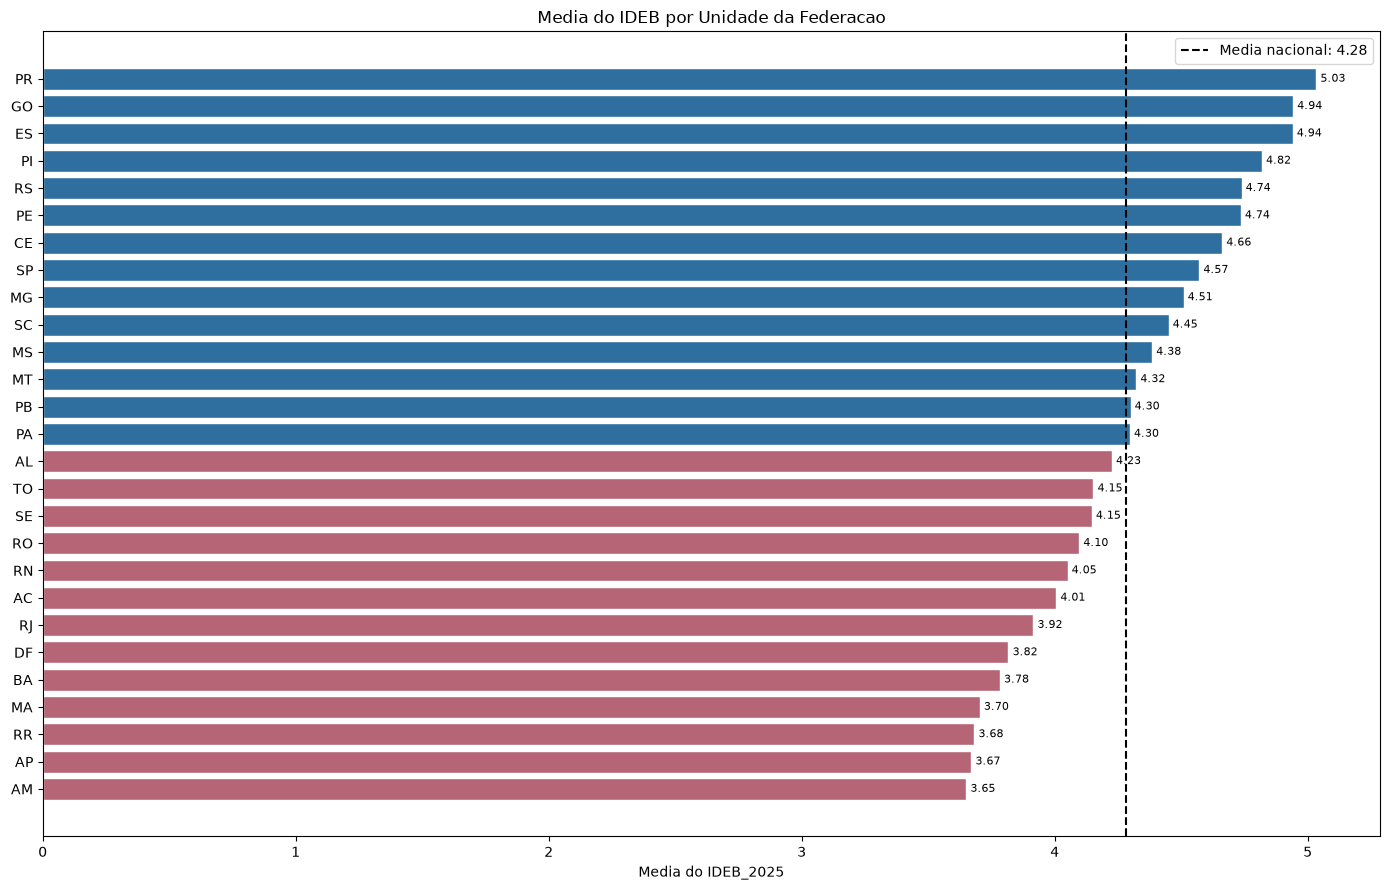

In [13]:
def graficoBarrasIdebPorUF(dados):
    if 'SG_UF' not in dados.columns:
        print('Coluna SG_UF nao encontrada no dataset.')
        return

    media_uf = (
        dados.groupby('SG_UF')['IDEB_2025']
        .agg(['mean', 'count'])
        .reset_index()
        .rename(columns={'mean': 'Media_IDEB', 'count': 'N_Escolas'})
        .sort_values('Media_IDEB')
    )

    fig, ax = plt.subplots(figsize=(14, 9))
    cores = ['#b56576' if v < media_uf['Media_IDEB'].mean() else '#2f6f9f' for v in media_uf['Media_IDEB']]
    bars = ax.barh(media_uf['SG_UF'], media_uf['Media_IDEB'], color=cores, edgecolor='white')
    ax.axvline(media_uf['Media_IDEB'].mean(), color='black', linestyle='--', label=f'Media nacional: {media_uf["Media_IDEB"].mean():.2f}')
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    ax.set_xlabel('Media do IDEB_2025')
    ax.set_title('Media do IDEB por Unidade da Federacao')
    ax.legend()
    plt.tight_layout()
    plt.savefig(CAMINHO_IMAGENS / 'ideb_por_uf.png', dpi=150, bbox_inches='tight')
    plt.show()

graficoBarrasIdebPorUF(df)


## 13. Scatter Plot - IDEB vs Variaveis-Chave

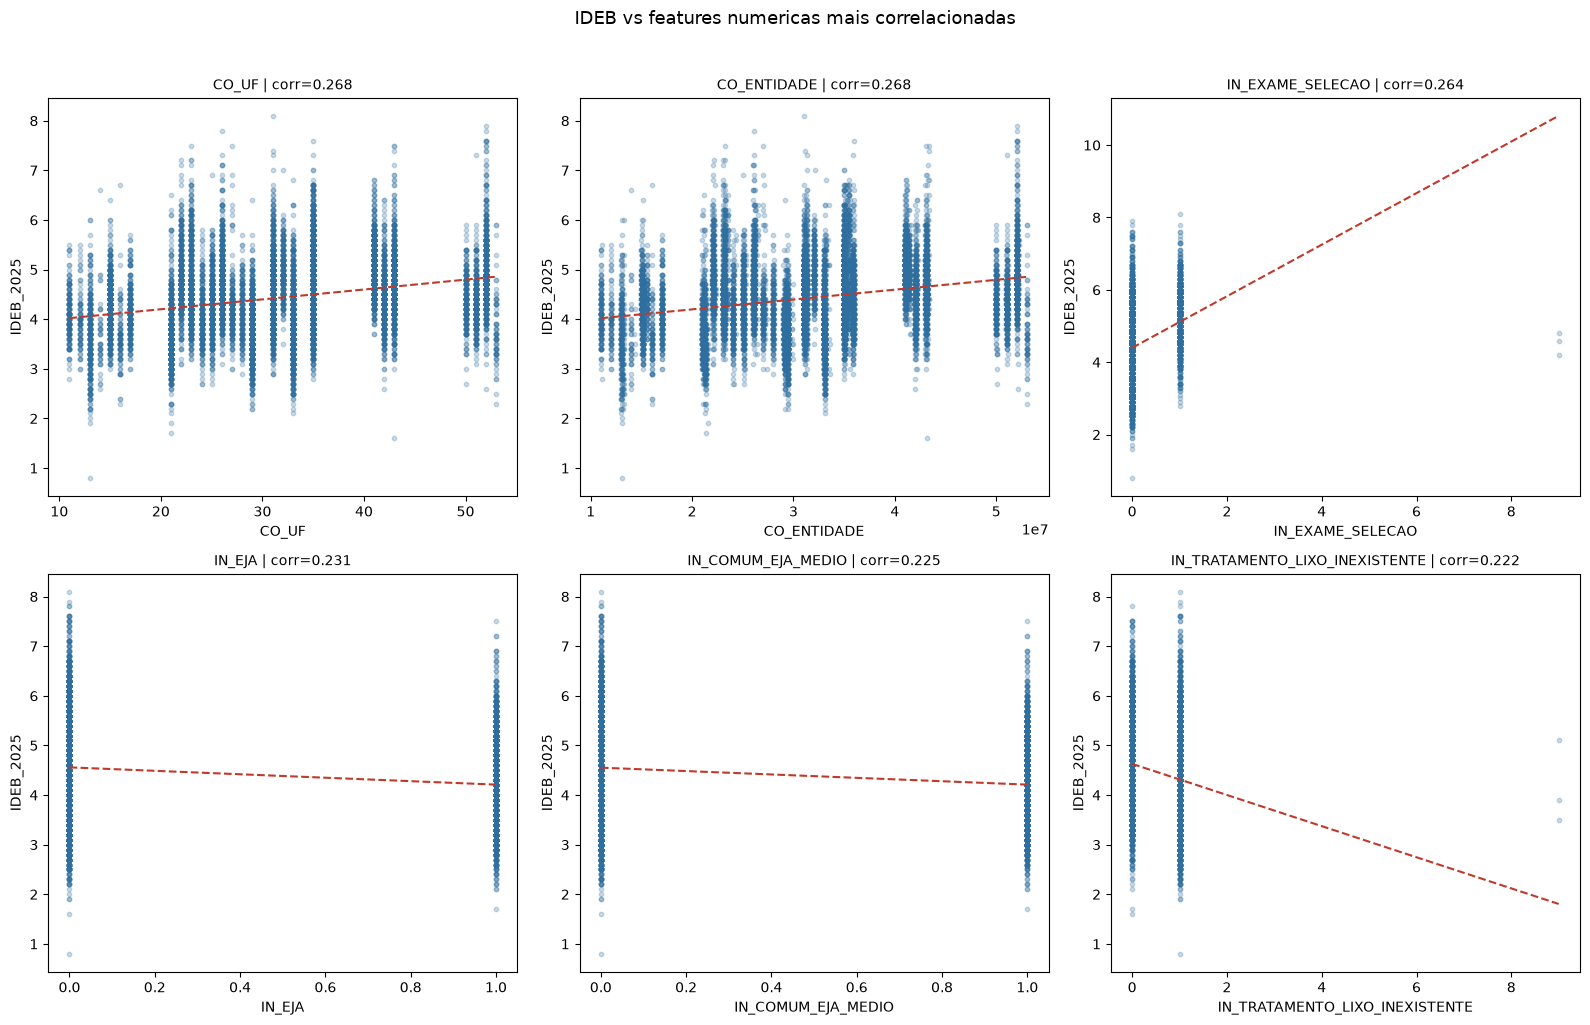

In [14]:
def scatterIdebVsFeatures(dados, n_features=6):
    numericas_local = dados.select_dtypes(include=[np.number]).dropna()
    correlacoes = numericas_local.corrwith(numericas_local['IDEB_2025']).abs()
    correlacoes = correlacoes.drop('IDEB_2025').sort_values(ascending=False)
    top_features = correlacoes.head(n_features).index.tolist()

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, col in enumerate(top_features):
        axes[i].scatter(dados[col], dados['IDEB_2025'], alpha=0.25, s=10, color='#2f6f9f')
        mask = dados[[col, 'IDEB_2025']].notna().all(axis=1)
        if dados.loc[mask, col].nunique() > 1:
            z = np.polyfit(dados.loc[mask, col], dados.loc[mask, 'IDEB_2025'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(dados[col].min(), dados[col].max(), 100)
            axes[i].plot(x_line, p(x_line), color='#c0392b', linestyle='--', linewidth=1.5)
        axes[i].set_title(f'{col} | corr={correlacoes[col]:.3f}', fontsize=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('IDEB_2025')

    for ax in axes[len(top_features):]:
        ax.axis('off')

    plt.suptitle('IDEB vs features numericas mais correlacionadas', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(CAMINHO_IMAGENS / 'scatter_ideb_features.png', dpi=150, bbox_inches='tight')
    plt.show()

scatterIdebVsFeatures(df)


---
## Conclusao

| Analise | Decisao |
|---|---|
| Distribuicoes e histogramas | Variaveis de contagem sao assimetricas; IQR sozinho nao deve remover escolas grandes validas |
| Boxplots | Existem extremos relevantes, principalmente em contagens e equipamentos |
| Codigos invalidos | Remover linhas com `88888` e indicadores `IN_*` fora de 0/1 apos retirar detalhamento ambiental |
| Baixa variancia | Remover colunas quase constantes, com pelo menos 99,5% dos registros no mesmo valor |
| Redundancia | Remover detalhamentos ambientais altamente redundantes e colunas duplicadas/derivadas |
| Identificadores/texto | Remover `SG_UF`, `NO_ENTIDADE` e `CO_ENTIDADE` para evitar identificadores e colunas nao numericas no treinamento |

> **Proximo passo:** aplicar essas regras no `02.Preparacao_dos_dados.ipynb` e manter `dados_tratados.csv` como base final limpa antes de executar o `05.Modelagem_Avaliacao.ipynb`.
